In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("qiriro/swell-heart-rate-variability-hrv")

print("Path to dataset files:", path)

c:\Users\Nikhil Sharma\Documents\Nikhil's Projects\Biomedical Project\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Nikhil Sharma\.cache\kagglehub\datasets\qiriro\swell-heart-rate-variability-hrv\versions\1


In [2]:
import os
import pandas as pd


In [3]:
train_file_path = os.path.join(path, 'hrv dataset', 'data', 'final', 'train.csv')

try:
    df_train = pd.read_csv(train_file_path)
    print(f"Successfully loaded {train_file_path}")
    display(df_train.head())
except FileNotFoundError:
    print(f"Error: {train_file_path} not found. Please check the file structure of the dataset.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")


Successfully loaded C:\Users\Nikhil Sharma\.cache\kagglehub\datasets\qiriro\swell-heart-rate-variability-hrv\versions\1\hrv dataset\data\final\train.csv


,MEAN_RR,MEDIAN_RR,SDRR,RMSSD,SDSD,SDRR_RMSSD,HR,pNN25,pNN50,SD1,...,HF,HF_PCT,HF_NU,TP,LF_HF,HF_LF,sampen,higuci,datasetId,condition
0,885.157845,853.763730,140.972741,15.554505,15.553371,9.063146,69.499952,11.133333,0.533333,11.001565,...,15.522603,0.421047,1.514737,3686.666157,65.018055,0.015380,2.139754,1.163485,2,no stress
1,939.425371,948.357865,81.317742,12.964439,12.964195,6.272369,64.363150,5.600000,0.000000,9.170129,...,2.108525,0.070133,0.304603,3006.487251,327.296635,0.003055,2.174499,1.084711,2,interruption
2,898.186047,907.006860,84.497236,16.305279,16.305274,5.182201,67.450066,13.066667,0.200000,11.533417,...,13.769729,0.512671,1.049528,2685.879461,94.280910,0.010607,2.135350,1.176315,2,interruption
3,881.757865,893.460030,90.370537,15.720468,15.720068,5.748591,68.809562,11.800000,0.133333,11.119476,...,18.181913,0.529387,1.775294,3434.520980,55.328701,0.018074,2.178341,1.179688,2,no stress
4,809.625331,811.184865,62.766242,19.213819,19.213657,3.266724,74.565728,20.200000,0.200000,13.590641,...,48.215822,1.839473,3.279993,2621.175204,29.487873,0.033912,2.221121,1.249612,2,no stress


In [4]:
# Drop missing values and extract features/target
df_cleaned = df_train.dropna()
print(f"Shape before dropping NaNs: {df_train.shape}")
print(f"Shape after dropping NaNs: {df_cleaned.shape}")

feature_mapping = {'HR': 'MEAN_RR', 'RMSSD': 'RMSSD', 'SDNN': 'SDRR', 'LF/HF': 'LF_HF'}
actual_feature_columns = [col for col in feature_mapping.values() if col in df_cleaned.columns]
missing_cols = [name for name, col in feature_mapping.items() if col not in df_cleaned.columns]
if missing_cols:
    print(f"Warning: The following requested feature concepts were not found in the DataFrame: {missing_cols}. Please verify the mapping or column existence.")

df_features = df_cleaned[actual_feature_columns].copy()
display(df_features.head())

y = df_cleaned['condition']
print(f"Shape of features (X): {df_features.shape}")
print(f"Shape of target (y): {y.shape}")
print("Data preparation complete. Displaying the first 5 rows of the extracted features and target variable.")


Shape before dropping NaNs: (369289, 36)
Shape after dropping NaNs: (369289, 36)


,MEAN_RR,RMSSD,SDRR,LF_HF
0,885.157845,15.554505,140.972741,65.018055
1,939.425371,12.964439,81.317742,327.296635
2,898.186047,16.305279,84.497236,94.280910
3,881.757865,15.720468,90.370537,55.328701
4,809.625331,19.213819,62.766242,29.487873


Shape of features (X): (369289, 4)
Shape of target (y): (369289,)
Data preparation complete. Displaying the first 5 rows of the extracted features and target variable.


## Exploratory Data Analysis (EDA)

Let's perform some basic EDA to understand the distribution of features and the target variable.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for numerical features
print("Descriptive Statistics for Features:")
display(df_features.describe())

Descriptive Statistics for Features:


,MEAN_RR,RMSSD,SDRR,LF_HF
count,369289.000000,369289.000000,369289.000000,369289.000000
mean,846.650104,14.977498,109.352531,115.977200
std,124.603984,4.120766,77.117025,360.855129
min,547.492221,5.529742,27.233947,2.319952
25%,760.228533,11.830959,64.205641,14.737458
50%,822.951438,14.415918,82.608243,28.789747
75%,924.117422,17.927144,118.237002,80.429614
max,1322.016957,26.629477,563.486949,7796.443096


### Correlation Matrix

Visualizing the correlation between the numerical features can reveal relationships between them.

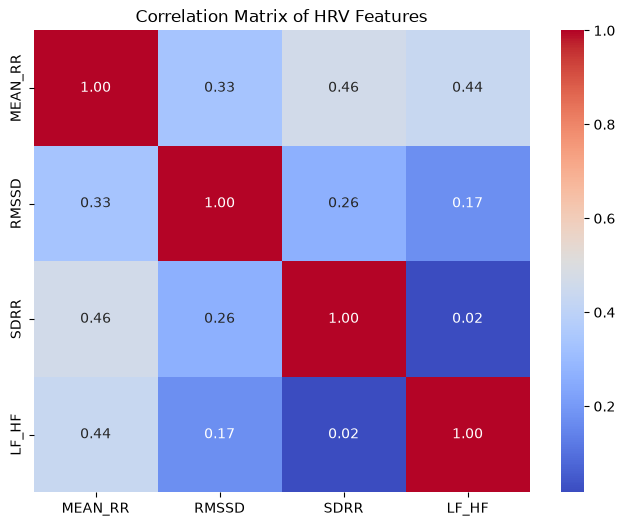

In [6]:
# Calculate the correlation matrix
correlation_matrix = df_features.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of HRV Features')
plt.show()

### Distribution of Features

Let's look at the distribution of each individual feature to identify any skewness or outliers.

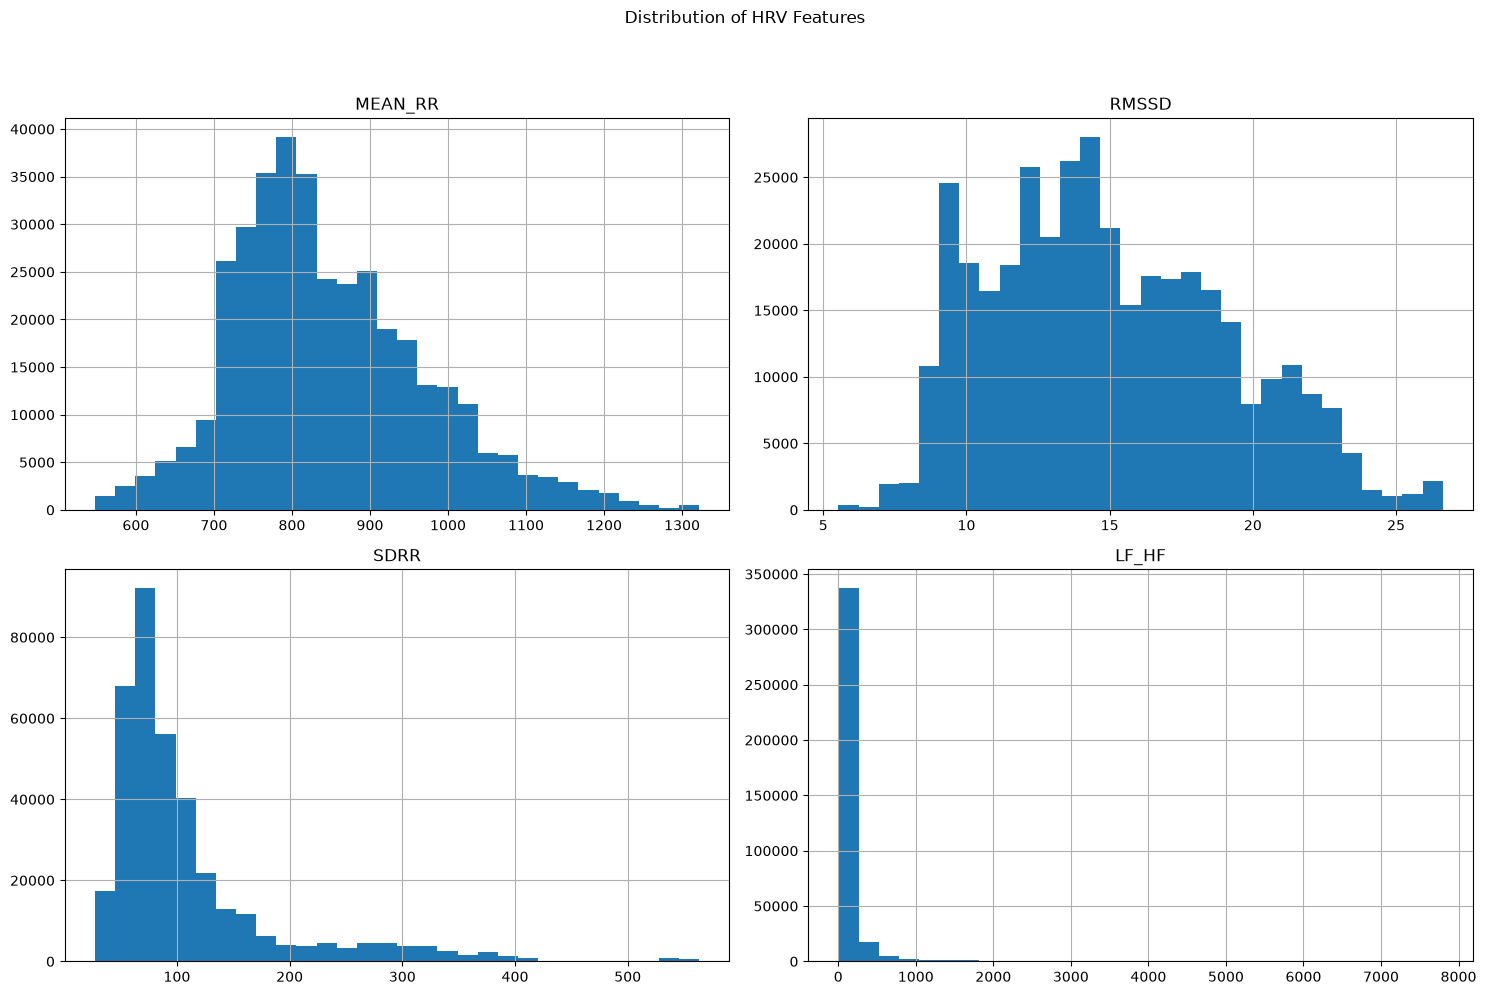

In [7]:
# Plot histograms for each feature
df_features.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of HRV Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

### Distribution of Target Variable

Understanding the balance of classes in our target variable (`condition`).

C:\Users\Nikhil Sharma\AppData\Local\Temp\ipykernel_13484\733445440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


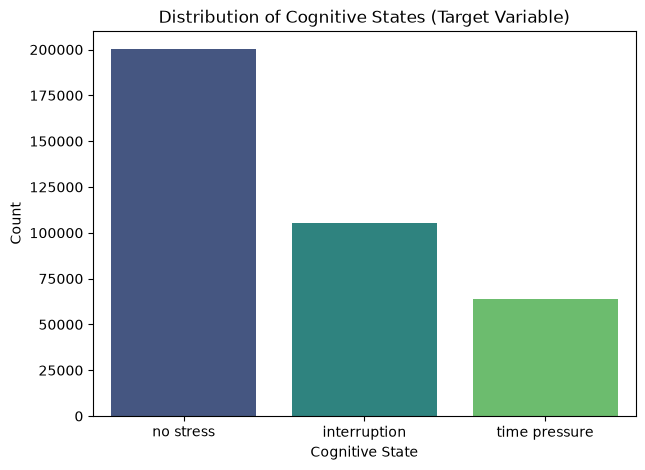

EDA steps complete.


In [8]:
# Plot the distribution of the target variable
plt.figure(figsize=(7, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Cognitive States (Target Variable)')
plt.xlabel('Cognitive State')
plt.ylabel('Count')
plt.show()

print("EDA steps complete.")

## Addressing Data Issues: Feature Transformation and Class Imbalance

Based on the EDA, we identified two key issues:
1.  **Right-skewness in `LF_HF`**: This can be addressed with a logarithmic transformation.
2.  **Class Imbalance in `condition`**: This can be handled by using class weights in the loss function during model training.

### Logarithmic Transformation for `LF_HF`

Applying `np.log1p` (log(1+x)) to the `LF_HF` feature to reduce its skewness. This transformation is suitable for features with non-negative values and a long right tail.

LF_HF feature transformed using log1p.


,MEAN_RR,RMSSD,SDRR,LF_HF
0,885.157845,15.554505,140.972741,4.189928
1,939.425371,12.964439,81.317742,5.793918
2,898.186047,16.305279,84.497236,4.556829
3,881.757865,15.720468,90.370537,4.031204
4,809.625331,19.213819,62.766242,3.417329


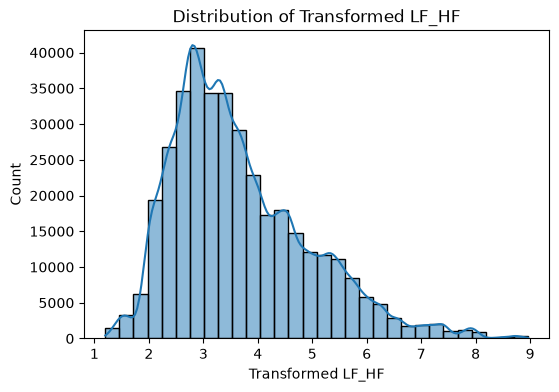

In [9]:
import numpy as np

# Apply log1p transformation to LF_HF
df_features['LF_HF_transformed'] = np.log1p(df_features['LF_HF'])

# Drop the original LF_HF column if you want to use the transformed one exclusively
df_features = df_features.drop(columns=['LF_HF'])

# Rename the transformed column back to LF_HF if desired for consistency
df_features = df_features.rename(columns={'LF_HF_transformed': 'LF_HF'})

print("LF_HF feature transformed using log1p.")
display(df_features.head())

# Optionally, visualize the new distribution
plt.figure(figsize=(6, 4))
sns.histplot(df_features['LF_HF'], bins=30, kde=True)
plt.title('Distribution of Transformed LF_HF')
plt.xlabel('Transformed LF_HF')
plt.ylabel('Count')
plt.show()

### Handling Class Imbalance with Class Weights

To address the class imbalance observed in the `condition` variable, we will calculate class weights. These weights will be used in the `CrossEntropyLoss` function in PyTorch, giving more importance to the minority classes during training.

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import torch

label_mapping = {'no stress': 0, 'interruption': 1, 'time pressure': 2}
y_numerical_for_weights = y.map(label_mapping).values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_numerical_for_weights),
    y=y_numerical_for_weights
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Calculated Class Weights:", class_weights_tensor)
print("Class weights computed for addressing imbalance. These will be applied to the loss function.")


Calculated Class Weights: tensor([0.6152, 1.1707, 1.9217])
Class weights computed for addressing imbalance. These will be applied to the loss function.


In [12]:
from sklearn.preprocessing import StandardScaler
import torch

# Standardize numerical metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

print("Features standardized successfully.")
print(f"Shape of scaled features: {X_scaled.shape}")

Features standardized successfully.
Shape of scaled features: (369289, 4)


In [13]:
# Convert target labels to numerical indices
# Mapping: 0: Relaxed (no stress), 1: Interrupted, 2: Time Pressure
# Assuming 'no stress' is Relaxed, 'interruption' is Interrupted, 'time pressure' is Time Pressure
label_mapping = {'no stress': 0, 'interruption': 1, 'time pressure': 2}

y_numerical = y.map(label_mapping).values

# Convert to PyTorch float tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_numerical, dtype=torch.long) # Use torch.long for classification labels

print("Data converted to PyTorch tensors successfully.")
print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")
print(f"First 5 target tensor values: {y_tensor[:5].tolist()}")
print("Step 2 (Normalization and Tensor Conversion) complete.")

Data converted to PyTorch tensors successfully.
Shape of X_tensor: torch.Size([369289, 4])
Shape of y_tensor: torch.Size([369289])
First 5 target tensor values: [0, 1, 1, 0, 0]
Step 2 (Normalization and Tensor Conversion) complete.


In [14]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

input_size = X_tensor.shape[1]
output_size = len(torch.unique(y_tensor))
hidden_size = 64
model = SimpleMLP(input_size, hidden_size, output_size)

print(f"MLP Model Architecture:\n{model}")
print(f"Input size: {input_size}, Hidden size: {hidden_size}, Output size: {output_size}")
print("MLP model defined.")


MLP Model Architecture:
SimpleMLP(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=3, bias=True)
)
Input size: 4, Hidden size: 64, Output size: 3
MLP model defined.


In [15]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Dataset split into training ({len(train_dataset)} samples) and testing ({len(test_dataset)} samples).")
print(f"DataLoaders created with batch size: {batch_size}.")


Dataset split into training (295431 samples) and testing (73858 samples).
DataLoaders created with batch size: 64.


In [16]:
import torch.nn as nn
import torch.optim as optim

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

print("Starting model training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = correct_train = total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    model.eval()
    test_running_loss = correct_test = total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            test_running_loss += criterion(outputs, labels).item()
            predicted = outputs.argmax(dim=1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_running_loss / len(test_loader)
    epoch_test_accuracy = 100 * correct_test / total_test
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_accuracy)

    print(f"Epoch {epoch+1}, Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.2f}%, Test Loss: {epoch_test_loss:.4f}, Test Accuracy: {epoch_test_accuracy:.2f}%")

print("Training complete.")


Starting model training...
Epoch 1, Train Loss: 0.5989, Train Accuracy: 72.28%, Test Loss: 0.4276, Test Accuracy: 81.21%
Epoch 2, Train Loss: 0.3680, Train Accuracy: 83.25%, Test Loss: 0.3196, Test Accuracy: 84.87%
Epoch 3, Train Loss: 0.2906, Train Accuracy: 87.21%, Test Loss: 0.2621, Test Accuracy: 89.95%
Epoch 4, Train Loss: 0.2492, Train Accuracy: 89.25%, Test Loss: 0.2304, Test Accuracy: 89.11%
Epoch 5, Train Loss: 0.2205, Train Accuracy: 90.52%, Test Loss: 0.1927, Test Accuracy: 91.80%
Epoch 6, Train Loss: 0.1998, Train Accuracy: 91.44%, Test Loss: 0.1772, Test Accuracy: 92.35%
Epoch 7, Train Loss: 0.1838, Train Accuracy: 92.07%, Test Loss: 0.1744, Test Accuracy: 91.85%
Epoch 8, Train Loss: 0.1722, Train Accuracy: 92.60%, Test Loss: 0.1817, Test Accuracy: 92.76%
Epoch 9, Train Loss: 0.1627, Train Accuracy: 92.97%, Test Loss: 0.1538, Test Accuracy: 93.57%
Epoch 10, Train Loss: 0.1542, Train Accuracy: 93.33%, Test Loss: 0.1604, Test Accuracy: 93.41%
Training complete.


### Training and Testing Accuracy/Loss Curves

Let's visualize how the model's performance evolved over epochs by plotting the training and testing accuracy and loss.

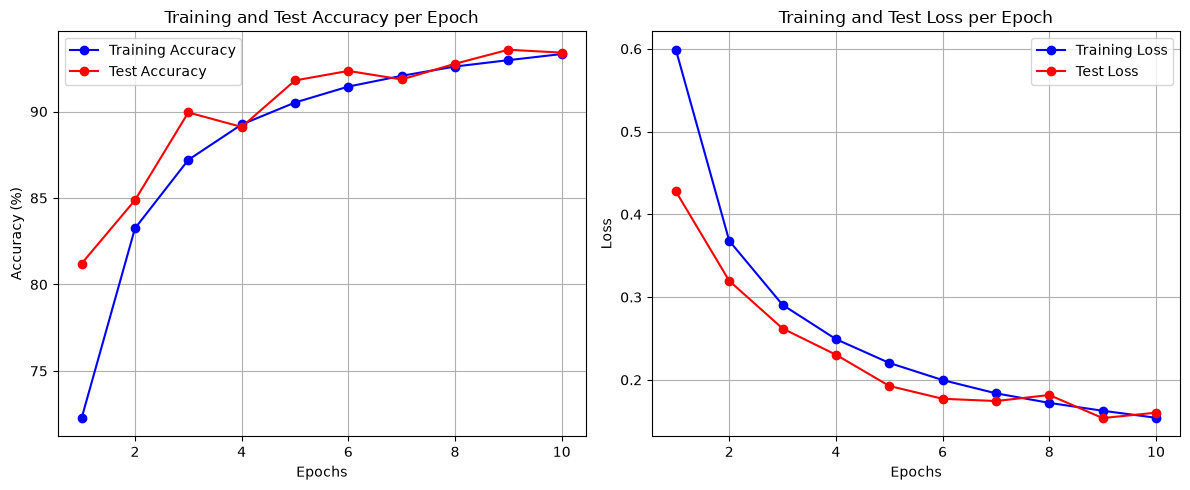

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(12, 5))

# Plot Training & Test Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
plt.plot(epochs, test_accuracies, 'ro-', label='Test Accuracy')
plt.title('Training and Test Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot Training & Test Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, test_losses, 'ro-', label='Test Loss')
plt.title('Training and Test Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Detailed Classification Metrics

Now, let's look at more detailed classification metrics such as the Confusion Matrix and a Classification Report (Precision, Recall, F1-score) to get a deeper understanding of the model's performance for each class.


Classification Report:
               precision    recall  f1-score   support

    no stress       0.97      0.93      0.95     39945
 interruption       0.95      0.94      0.94     21208
time pressure       0.83      0.95      0.89     12705

     accuracy                           0.93     73858
    macro avg       0.91      0.94      0.93     73858
 weighted avg       0.94      0.93      0.93     73858



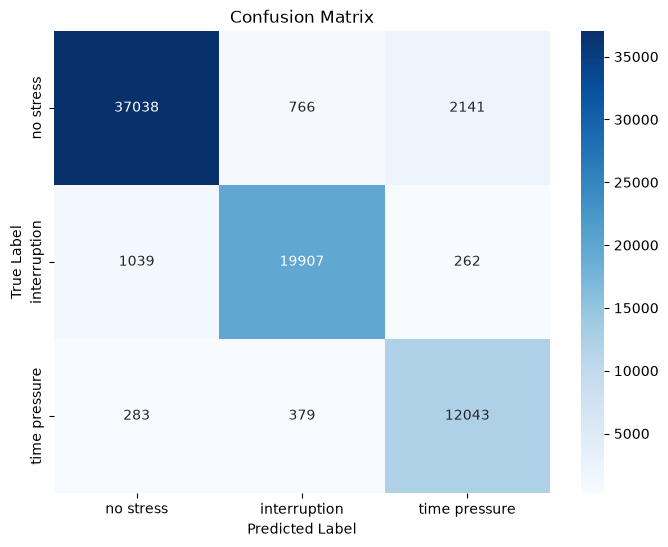

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

all_true_labels, all_predicted_labels, all_predicted_probs = [], [], []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        all_true_labels.extend(labels.numpy())
        all_predicted_labels.extend(outputs.argmax(dim=1).numpy())
        all_predicted_probs.extend(torch.softmax(outputs, dim=1).numpy())

all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)
all_predicted_probs = np.array(all_predicted_probs)

print("\nClassification Report:")
print(classification_report(all_true_labels, all_predicted_labels, target_names=label_mapping.keys()))

conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Multi-class ROC-AUC Curve

Finally, let's visualize the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) for each class to assess the model's ability to distinguish between classes.

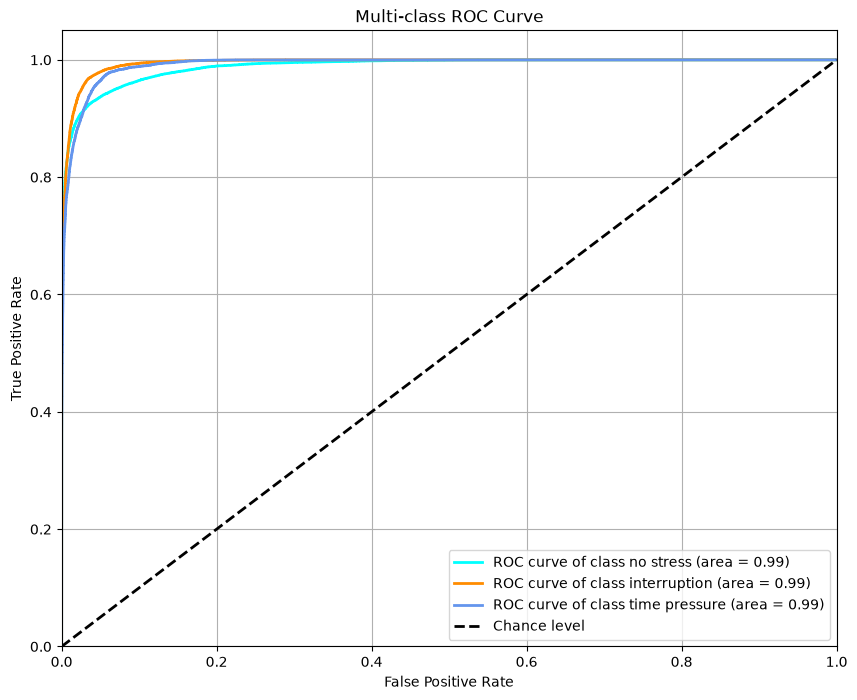

In [19]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Assuming `all_true_labels` and `all_predicted_probs` are already computed

n_classes = len(label_mapping) # Number of unique classes

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_true_labels == i, all_predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(list(label_mapping.keys())[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [20]:
model.eval()
correct = total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        predicted = model(inputs).argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}%")
print("Step 3 (Neural Net Classification) complete.")


Accuracy on the test set: 93.41%
Step 3 (Neural Net Classification) complete.


In [21]:
# Step 4: Intervention Mapping

# Define the Item Index Catalog
# Maps model output indices (cognitive states) to categories of wellness suggestions
# 0: Relaxed, 1: Interrupted, 2: Time Pressure
intervention_catalog = {
    0: "Focus Boosters (e.g., short meditation, deep work playlist)",
    1: "Mindfulness & Re-focusing Techniques (e.g., 5-minute breathing exercise, quick stretch)",
    2: "Stress Reduction & Grounding Exercises (e.g., progressive muscle relaxation, guided imagery, short break)"
}

print("Item Index Catalog created:")
for state_index, suggestions in intervention_catalog.items():
    print(f"State {state_index}: {suggestions}")

print("Step 4 (Intervention Mapping) complete.")

Item Index Catalog created:
State 0: Focus Boosters (e.g., short meditation, deep work playlist)
State 1: Mindfulness & Re-focusing Techniques (e.g., 5-minute breathing exercise, quick stretch)
State 2: Stress Reduction & Grounding Exercises (e.g., progressive muscle relaxation, guided imagery, short break)
Step 4 (Intervention Mapping) complete.


In [22]:
# Step 5: Neural Recommendation

model.eval()
predicted_states = []
with torch.no_grad():
    for inputs, _ in test_loader:
        predicted_states.extend(model(inputs).argmax(dim=1).numpy())

recommended_interventions = [intervention_catalog[state] for state in predicted_states]
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

print("Example Neural Recommendations (first 10 from test set):")
for i in range(10):
    true_label = test_dataset[i][1].item()
    predicted_state = predicted_states[i]
    intervention = recommended_interventions[i]
    true_state_str = reverse_label_mapping.get(true_label, f"Unknown ({true_label})")
    predicted_state_str = reverse_label_mapping.get(predicted_state, f"Unknown ({predicted_state})")

    print(f"  Sample {i+1}: True State: {true_state_str}, Predicted State: {predicted_state_str}, Recommended Intervention: {intervention}")

print("Step 5 (Neural Recommendation) complete.")


Example Neural Recommendations (first 10 from test set):
  Sample 1: True State: no stress, Predicted State: no stress, Recommended Intervention: Focus Boosters (e.g., short meditation, deep work playlist)
  Sample 2: True State: no stress, Predicted State: no stress, Recommended Intervention: Focus Boosters (e.g., short meditation, deep work playlist)
  Sample 3: True State: interruption, Predicted State: interruption, Recommended Intervention: Mindfulness & Re-focusing Techniques (e.g., 5-minute breathing exercise, quick stretch)
  Sample 4: True State: no stress, Predicted State: no stress, Recommended Intervention: Focus Boosters (e.g., short meditation, deep work playlist)
  Sample 5: True State: no stress, Predicted State: no stress, Recommended Intervention: Focus Boosters (e.g., short meditation, deep work playlist)
  Sample 6: True State: no stress, Predicted State: no stress, Recommended Intervention: Focus Boosters (e.g., short meditation, deep work playlist)
  Sample 7: Tru

In [23]:
# Step 6: Validation (Calculate Cross-Entropy Loss on test set)

# Ensure the model is in evaluation mode
model.eval()

test_loss = 0.0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

# Calculate average test loss
average_test_loss = test_loss / len(test_loader)

print(f"Cross-Entropy Loss on the test set: {average_test_loss:.4f}")
print(f"Accuracy on the test set: {accuracy:.2f}%") # Re-displaying accuracy for completeness

print("Step 6 (Validation) complete.")

Cross-Entropy Loss on the test set: 0.1604
Accuracy on the test set: 93.41%
Step 6 (Validation) complete.


In [24]:
torch.save({
    "model": model.state_dict(),
    "scaler": scaler
}, "hrv_model.pth")